## Imports

In [5]:
from juliacall import Main as jl
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

jl.include("SolarDynamo.jl")
jl.seval("using .SolarDynamo")
sn = jl.SolarDynamo.sn
sn_from_noise = jl.SolarDynamo.sn_from_noise

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Global settings

In [6]:
TOBS = 200 # how many time steps to simulate
TWARMUP = 200 # time steps that are discarded
DT = 0.1 # Euler-Maruyama internal step
PARAM_NAMES = ["tau", "T", "Nd", "sigma", "Bmax"]
USE_FOURIER = False
FOURIER_SIZE = TOBS // 2 + 1
COLORS = ["dodgerblue", "darkorange", "deeppink"]

## Simulator

In [7]:
def simulate(theta, seed=None):
    tau, T, Nd, sigma, Bmax = theta
    T = round(T / DT) * DT
    
    if seed is not None:
        np.random.seed(seed)
    
    # generate noise
    Ndt = int( (TWARMUP+TOBS) / DT ) # = 4000 if TWARMUP=200,TOBS=200,DT=0.1
    eps_dt = np.random.randn(Ndt).astype(np.float64)
    
    # convert to julia types
    theta_jl = jl.Vector[jl.Float64]([tau, T, Nd, sigma, Bmax])
    eps_jl = jl.Vector[jl.Float64](eps_dt)
    
    # stochastic simulation
    x = sn_from_noise(theta_jl, eps_jl, Twarmup=TWARMUP, Tobs=TOBS, dt=DT)
    x = np.array(x, dtype=np.float32)
    
    # extract from eps_dt just the non-warmup portion
    warmup_steps = int(TWARMUP / DT)
    # compute the sum of noise per block
    k = int(1.0/DT)
    eps_obs = np.array([
        np.sum( eps_dt[warmup_steps+i*k : warmup_steps + (i+1)*k] )
        for i in range(TOBS)], dtype=np.float32)
    eps_obs /= np.sqrt(k)
    
    return x, eps_obs

In [8]:
def to_fourier(X):
    F = np.abs(np.fft.rfft(X, axis=1)) # (n_samples, TOBS//2 + 1)
    F = np.log1p(F) # compress the dynamic range
    return F.astype(np.float32)

## Helpers

In [9]:
def make_basename(n_samples, fixed, prior):
    fixed_text = "-".join([str(v) for v in fixed.values()])
    prior_text = "_".join([
        f"{k}={priors[k][0]},{priors[k][1]}"
        for k in PARAM_NAMES
        if fixed.get(k) is None and isinstance(priors.get(k), tuple)
    ])
    fourier_text = "fourier" if USE_FOURIER else "time"
    return f"{n_samples}__{fixed_text}__{prior_text}__{fourier_text}"

In [10]:
def get_output_size():
    return FOURIER_SIZE if USE_FOURIER else TOBS

In [11]:
def plot_loss(loss_history):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(loss_history[:,0], label="Total",
           c=COLORS[0], lw=3)
    ax.plot(loss_history[:,1], linestyle="--", 
            label="Reconstruction", c=COLORS[1], lw=3)
    ax.plot(loss_history[:,2], linestyle=":", 
            label="Regression", c=COLORS[2], lw=3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title("Training Loss Curves")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [32]:
def experiment(fixed, priors, n_train, n_test, n_summary, epochs, train_model=True):
    # generate dataset for training and test
    generate_train_test_datasets(fixed, priors, n_train=n_train, n_test=n_test)
    data = load_train_test_datasets(fixed, priors, n_train=n_train, n_test=n_test)

    if train_model:
        # train and evaluate model
        model, s, x_hat = run(fixed, priors, data, n_summary=n_summary, epochs=epochs)
    else:
        # load model
        model, loss_history = load_model(fixed, priors, n_summary=n_summary)
        plot_loss(loss_history)
        s, x_hat = evaluate(model, data["X_test"], data["N_test"],
                            data["P_test"], data["stats"], fixed)
    return model, s, x_hat

## Dataset generator

In [12]:
def generate_dataset(n_samples, fixed, priors):
    varying_names = [k for k,v in fixed.items() if v is None]
    n_params = len(varying_names)
    
    # create the dataset
    X = np.zeros((n_samples, TOBS), dtype=np.float32)
    Noise = np.zeros((n_samples, TOBS), dtype=np.float32)
    Params = np.zeros((n_samples, n_params), dtype=np.float32)

    for i in range(n_samples):
        theta = {}
        for name in PARAM_NAMES:
            if fixed[name] is not None:
                theta[name] = fixed[name]
            else:
                low, high = priors[name]
                theta[name] = np.random.uniform(low,high)
                
        x, noise = simulate([theta[k] for k in PARAM_NAMES])
        X[i] = x
        Noise[i] = noise
        Params[i] = [theta[k] for k in varying_names]

        if (i+1)%50 == 0:
            print(f"Generated {i+1}/{n_samples} samples", end="\r")
    
    print()
    
    # check if X in Fourier Space or Time Space
    if USE_FOURIER:
        X = to_fourier(X)
    
    # normalize x
    x_mean = X.mean()
    x_std = X.std()

    # don't normalize noise because already normalized
    n_mean = 0
    n_std = 1

    # normalize parameters
    p_mean = Params.mean(axis=0)
    p_std  = Params.std(axis=0)
    p_std[p_std == 0] = 1.0
        
    stats = {
        "x_mean": x_mean, "x_std": x_std,
        "n_mean": n_mean, "n_std": n_std,
        "p_mean": p_mean, "p_std": p_std
    }
    
    X = (X - x_mean) / x_std
    Params = (Params - p_mean) / p_std
    
    return X, Noise, Params, stats

## Saving / Loading datasets

In [13]:
def save_dataset(X, Noise, Params, stats, n_samples, fixed, priors, folder="data"):
    os.makedirs(folder, exist_ok=True)
    
    base = make_basename(n_samples, fixed, priors)
        
    np.save(os.path.join(folder, f"X_{base}.npy"), X)
    np.save(os.path.join(folder, f"Noise_{base}.npy"), Noise)
    np.save(os.path.join(folder, f"Params_{base}.npy"), Params)
    np.save(os.path.join(folder, f"stats_{base}.npy"), stats, allow_pickle=True)
    print(f"Saved → {folder}/{base}\n")

def load_dataset(n_samples, fixed, priors, folder="data"):
    base = make_basename(n_samples, fixed, priors)
    
    try:
        X = np.load(os.path.join(folder, f"X_{base}.npy"))
        Noise = np.load(os.path.join(folder, f"Noise_{base}.npy"))
        Params = np.load(os.path.join(folder, f"Params_{base}.npy"))
        stats = np.load(os.path.join(folder, f"stats_{base}.npy"), 
                        allow_pickle=True).item()
        print(f"Loaded ← {folder}/{base}")
        return X, Noise, Params, stats
    
    except FileNotFoundError:
        print(f"Not found: {base}. Generate it first.")
        return None

In [14]:
def generate_train_test_datasets(fixed, priors,
                                 n_train=5000, n_test=1000,
                                 folder="data"):
    # check if exists
    base = make_basename(n_train, fixed, priors)
    if os.path.isfile(os.path.join(folder, f"X_{base}.npy")):
        print("Dataset already exists, skipping generation.")
        return
    
    # generate and save a training dataset
    print("Generating training data...")
    X_tr, N_tr, P_tr, stats = generate_dataset(n_train, fixed, priors)
    save_dataset(X_tr, N_tr, P_tr, stats, n_train, fixed, priors, folder)

    # generate and save a test dataset
    print("Generating test data...")
    X_te, N_te, P_te, _ = generate_dataset(n_test, fixed, priors)
    save_dataset(X_te, N_te, P_te, stats, n_test, fixed, priors, folder)
    
    print("Done.")
    
def load_train_test_datasets(fixed, priors,
                             n_train=5000, n_test=1000,
                             folder="data"):
    # load datasets
    result_tr = load_dataset(n_train, fixed, priors, folder)
    result_te = load_dataset(n_test,  fixed, priors, folder)
    if result_tr is None or result_te is None:
        return None
    
    X_tr, N_tr, P_tr, stats = result_tr
    X_te, N_te, P_te, _     = result_te
    return {
        "X_train": X_tr, "N_train": N_tr, "P_train": P_tr, "stats": stats,
        "X_test":  X_te, "N_test":  N_te, "P_test":  P_te
    }

In [15]:
def save_model(model, loss_history, fixed, priors, n_summary, folder="models"):
    os.makedirs(folder, exist_ok=True)
    base = make_basename(0, fixed, priors).split("__", 1)[1]  # reuse naming logic
    path = os.path.join(folder, f"enca__{base}__{n_summary}summary.pt")
    torch.save({
        "model_state": model.state_dict(),
        "loss_history": loss_history
    }, path)
    print(f"Model saved → {path}")
    return path

def load_model(fixed, priors, n_summary, folder="models"):
    base = make_basename(0, fixed, priors).split("__", 1)[1]
    path = os.path.join(folder, f"enca__{base}__{n_summary}summary.pt")
    model = ENCA(n_summary)
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()
    print(f"Model loaded ← {path}")
    return model, checkpoint["loss_history"]

## ENCA Architecture

In [16]:
class Encoder(nn.Module):
    def __init__(self, n_summary):
        super().__init__()
        
        self.net = nn.Sequential(
            # block 1
            nn.Conv1d(1,  16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2), # halve the time dimension
            
            # block 2
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            
            # project to n_summary channels
            nn.Conv1d(32, n_summary, kernel_size=3, padding=1),
        )
        
        # average over time: (batch,n_summary,TOBS)->(batch,n_summary,1)
        self.pool = nn.AdaptiveAvgPool1d(1)
    
    def forward(self, x):
        # x: (batch,TOBS) -> add channel dim -> (batch,1,TOBS)
        x = x.unsqueeze(1)
        # x -> (batch,n_summary,TOBS/2)
        x = self.net(x)
        # x -> (batch,n_summary,1)
        x = self.pool(x)
        # x -> (batch,n_summary)
        x = x.squeeze(-1)
        
        return x


class Decoder(nn.Module):
    def __init__(self, n_summary):
        super().__init__()
        
        self.lstm = nn.LSTM(input_size=n_summary + 1, hidden_size=16, 
                            num_layers=2, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, s, noise):
        s_tiled = s.unsqueeze(1).expand(-1, noise.shape[1], -1)
        noise3d = noise.unsqueeze(2) 
        inp = torch.cat([s_tiled, noise3d], dim=-1)
        
        out, _ = self.lstm(inp)
        x_hat = self.fc(out).squeeze(-1)
        
        # resize output for Fourier or Time Space
        target_len = get_output_size()
        if x_hat.shape[1] != target_len:
            x_hat = nn.functional.interpolate(
                x_hat.unsqueeze(1), size=target_len, mode="linear", align_corners=False
            ).squeeze(1)
        
        return x_hat


class ENCA(nn.Module):
    def __init__(self, n_summary):
        super().__init__()
        
        self.encoder = Encoder(n_summary)
        self.decoder = Decoder(n_summary)
    
    def forward(self, x, noise):
        s = self.encoder(x)
        x_hat = self.decoder(s, noise)
        return s, x_hat

## Training and Evaluation

In [17]:
def train(X, Noise, Params, n_summary=None, epochs=200,
          batch_size=64, lr=1e-3):
    
    n_params = Params.shape[1]
    n_summary = n_summary or n_params+2
    
    # create the iterable dataset
    dataset = TensorDataset(
        torch.tensor(X),
        torch.tensor(Noise),
        torch.tensor(Params)
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # define model, optimizer and loss function
    model = ENCA(n_summary)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # change LR at each epoch with a scheduler
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)
    loss_func = nn.MSELoss()
    
    loss_history = []
    model.train()
    
    for epoch in range(epochs):
        total_loss = [0, 0, 0]
        n_batches = 0
        
        for x_batch, n_batch, p_batch in loader:            
            # get output from the model
            s, x_hat = model(x_batch, n_batch)
            
            # calculate reconstruction loss and regression loss 
            loss_recon = loss_func(x_hat, x_batch)
            loss_regr = loss_func(s[:, :n_params], p_batch)
            loss_tot = loss_recon + loss_regr
            
            # backpropagate loss
            optimizer.zero_grad()
            loss_tot.backward()
            optimizer.step()
            
            total_loss[0] += loss_tot.item()
            total_loss[1] += loss_recon.item()
            total_loss[2] += loss_regr.item()
            n_batches += 1
        
        # save dataset loss
        avg_loss = [l/n_batches for l in total_loss]
        loss_history.append(avg_loss)
        
        # update learning rate
        scheduler.step()
        
        if (epoch+1)%20 == 0:
            lr_now = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch+1:3d}, Loss: {avg_loss[0]:.4f}, LR: {lr_now:.2e}")
            
    # plot loss curves
    loss_history = torch.tensor(loss_history)
    
    return model, loss_history

In [18]:
def evaluate(model, X, Noise, Params, stats, fixed):
    varying_names = [k for k,v in fixed.items() if v is None]
    n_params = len(varying_names)
    
    # prediction
    model.eval()
    with torch.no_grad():
        s, x_hat = model(torch.tensor(X), torch.tensor(Noise))
    
    # convert to numpy
    s = s.numpy()
    x_hat = x_hat.numpy()
    
    # un-noralize paramters and summaries to real values
    Params_real = Params*stats["p_std"] + stats["p_mean"]
    s_real = s.copy()
    s_real[:, :n_params] = s[:, :n_params] * stats["p_std"] + stats["p_mean"]
    
    # 1) plot reconstruction (3 random examples)
    idx = np.random.choice(len(X), size=3, replace=False)
    fig, axes = plt.subplots(3,1,figsize=(10, 8),sharex=True)
    for ax,i in zip(axes,idx):
        title = ", ".join([f"{p}={Params_real[i,j]:.2f}" 
                           for j,p in enumerate(varying_names)])
        
        ax.plot(X[i], label="Original x", 
                c=COLORS[0], lw=3)
        ax.plot(x_hat[i], label="Reconstructed", 
                c=COLORS[1], lw=3, ls="--")
        ax.set_title(title)
    
    axes[0].legend()
    axes[-1].set_xlabel("time step")
    plt.suptitle("Reconstruction of data")
    plt.tight_layout()
    plt.show()
    
    # 2) plot s_j vs true param    
    fig, axes = plt.subplots(1, n_params, figsize=(4*n_params,4))
    if n_params == 1:
        axes = [axes]
    for i,(ax,name) in enumerate(zip(axes,varying_names)):
        ax.scatter(s_real[:,i], Params_real[:,i], alpha=0.3, 
                   s=8, c=COLORS[0])
        ax.set_ylabel(f"true {name}")
        ax.set_xlabel(f"$s_{i}$")
        ax.set_title(f"$s_{i}$ vs {name}")
    plt.suptitle("Regression check")
    plt.tight_layout()
    plt.show()
    
    # 3) plot latent space    
    fig, ax = plt.subplots(figsize=(6,5))
    sc = ax.scatter(s[:,0], s[:,1], c=Params_real[:,0], 
                    cmap="plasma", alpha=0.4, s=15)
    plt.colorbar(sc, ax=ax, label=varying_names[0])
    ax.set_ylabel("$s_1$")
    ax.set_xlabel("$s_0$")
    plt.suptitle(f"Latent space colored by {varying_names[0]}")
    plt.tight_layout()
    plt.show()
    
    return s, x_hat

In [21]:
def run(fixed, priors, data, n_summary=None, epochs=200, 
        batch_size=64, lr=1e-3):
    
    n_params = data["P_train"].shape[1]
    n_summary = n_summary or n_params + 2
    
    print("\nTraining...\n")
    model, loss_history = train(data["X_train"], data["N_train"], data["P_train"], 
                  n_summary=n_summary, epochs=epochs,
                  batch_size=batch_size, lr=lr)
    
    plot_loss(loss_history)
    save_model(model, loss_history, fixed, priors, n_summary)
    
    # evaluating
    print("\n" + 100*"-" + "\nEvaluating on test set...")
    s, x_hat = evaluate(model, data["X_test"], data["N_test"],
                        data["P_test"], data["stats"], fixed)
    
    return model, s, x_hat

---
# Exploring $\tau$ and T parameter space

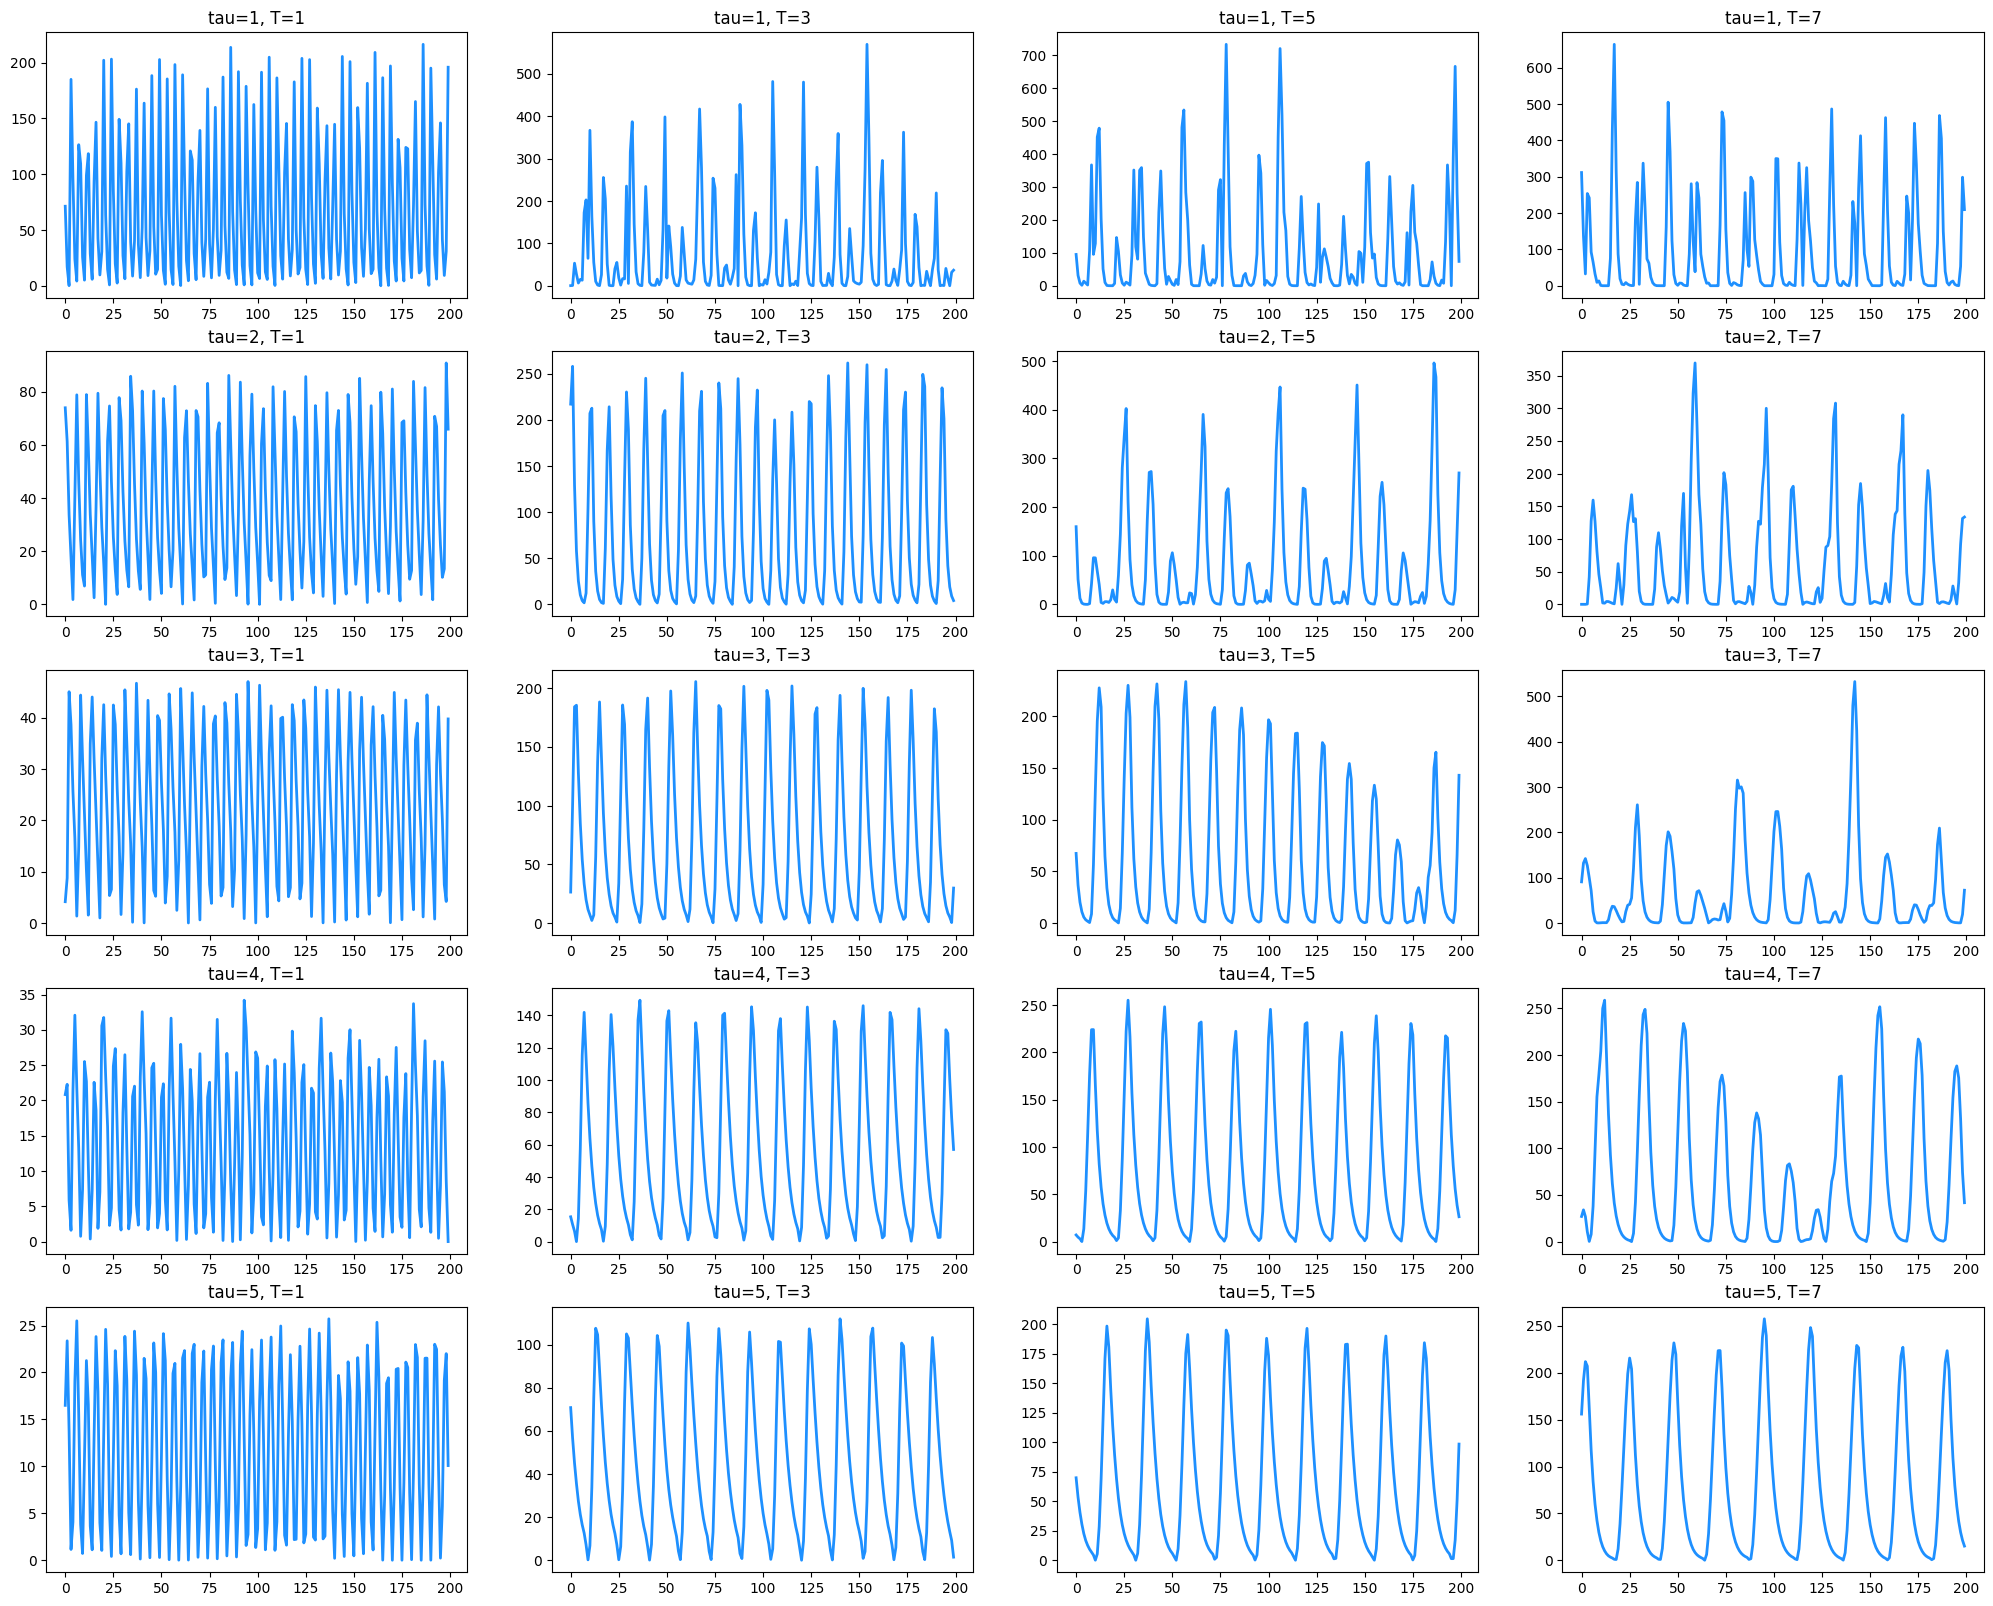

In [13]:
list_tau, list_T = [1, 2, 3, 4, 5], [1, 3, 5, 7]
fig,axes = plt.subplots(len(list_tau),len(list_T), 
                        figsize=(20+len(list_tau),20))
for i,tau in enumerate(list_tau):
    for j,T in enumerate(list_T):
        params = [tau, T, 11, 0.05, 5]
        x, _ = simulate(params)
        axes[i,j].plot(x, label=f"tau={tau}, T={T}", 
                       c=COLORS[0], lw=2)
        axes[i,j].set_title(f"tau={tau}, T={T}")

plt.show()

---
# Fixing 4 parameters 
## Vary $N_d$

Generating training data...
Generated 10000/10000 samples
Saved → data/10000__2.8-3.7-None-0.05-5__Nd=10,12__time

Generating test data...
Generated 1000/1000 samples
Saved → data/1000__2.8-3.7-None-0.05-5__Nd=10,12__time

Done.
Loaded ← data/10000__2.8-3.7-None-0.05-5__Nd=10,12__time
Loaded ← data/1000__2.8-3.7-None-0.05-5__Nd=10,12__time

Training...

Epoch  20, Loss: 0.2933, LR: 8.18e-04
Epoch  40, Loss: 0.2476, LR: 6.69e-04
Epoch  60, Loss: 0.1855, LR: 5.47e-04
Epoch  80, Loss: 0.1477, LR: 4.48e-04
Epoch 100, Loss: 1.0098, LR: 3.66e-04
Epoch 120, Loss: 0.4127, LR: 2.99e-04
Epoch 140, Loss: 0.2451, LR: 2.45e-04
Epoch 160, Loss: 0.2109, LR: 2.00e-04
Epoch 180, Loss: 0.1854, LR: 1.64e-04
Epoch 200, Loss: 0.1718, LR: 1.34e-04


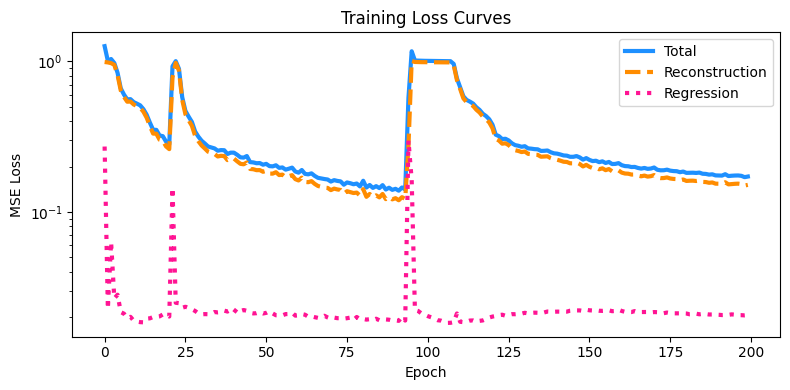

Model saved → models/enca__2.8-3.7-None-0.05-5__Nd=10,12__time__2summary.pt

----------------------------------------------------------------------------------------------------
Evaluating on test set...


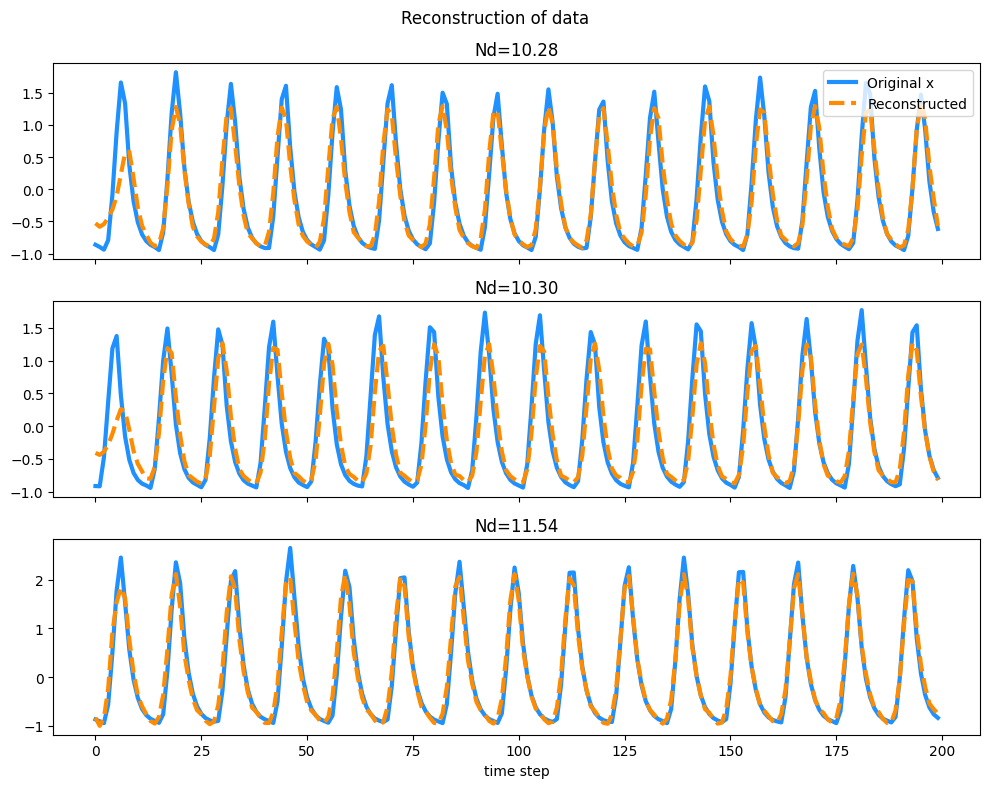

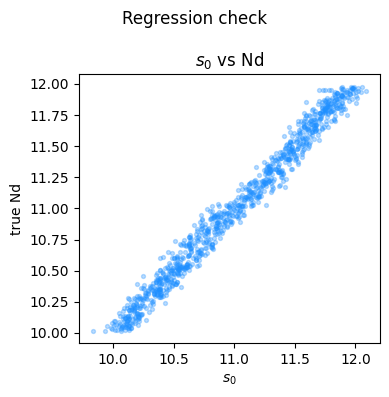

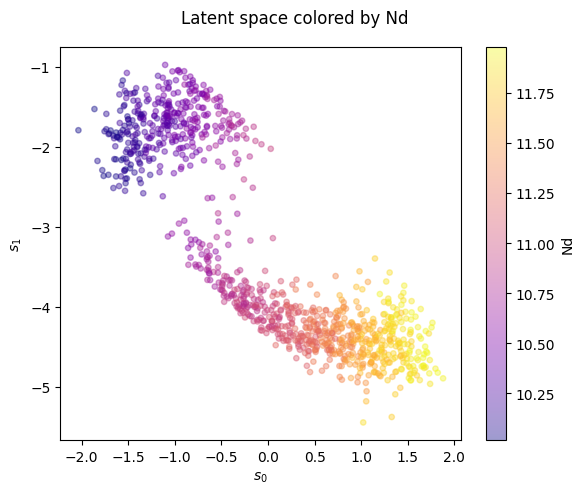

In [33]:
priors = {
    "tau": (1,5), 
    "T": (1,3), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": 2.8,
    "T": 3.7, 
    "Nd": None, 
    "sigma": 0.05, 
    "Bmax": 5
}

USE_FOURIER = False # if False, the Time Space is used for X

model, s, x_hat = experiment(fixed, priors,
                              n_train=10000, n_test=1000,
                              n_summary=2, epochs=200,
                              train_model=False)

---
# Fixing 2 parameters 
## Vary $N_d$ and $\sigma$

Generating training data...
Generated 10000/10000 samples
Saved → data/10000__2.8-3.7-None-None-5__Nd=10,12_sigma=0,0.3__time

Generating test data...
Generated 1000/1000 samples
Saved → data/1000__2.8-3.7-None-None-5__Nd=10,12_sigma=0,0.3__time

Done.
Loaded ← data/10000__2.8-3.7-None-None-5__Nd=10,12_sigma=0,0.3__time
Loaded ← data/1000__2.8-3.7-None-None-5__Nd=10,12_sigma=0,0.3__time

Training...

Epoch  20, Loss: 1.1506, LR: 8.18e-04
Epoch  40, Loss: 1.0526, LR: 6.69e-04
Epoch  60, Loss: 0.9502, LR: 5.47e-04
Epoch  80, Loss: 0.8902, LR: 4.48e-04
Epoch 100, Loss: 0.8213, LR: 3.66e-04
Epoch 120, Loss: 0.7672, LR: 2.99e-04
Epoch 140, Loss: 0.7225, LR: 2.45e-04
Epoch 160, Loss: 0.6979, LR: 2.00e-04
Epoch 180, Loss: 0.6748, LR: 1.64e-04
Epoch 200, Loss: 0.6679, LR: 1.34e-04


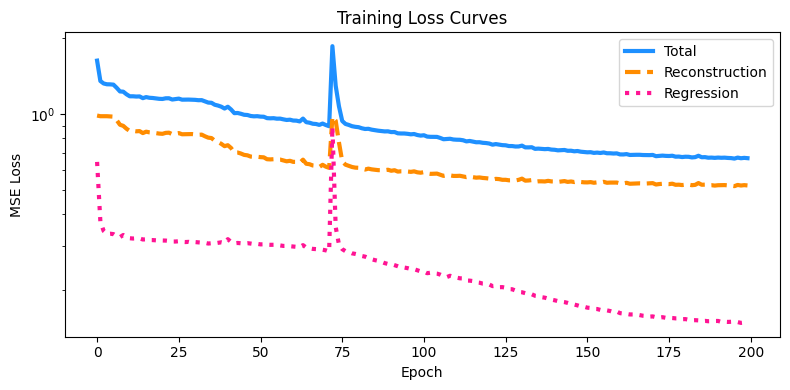

Model saved → models/enca__2.8-3.7-None-None-5__Nd=10,12_sigma=0,0.3__time__3summary.pt

----------------------------------------------------------------------------------------------------
Evaluating on test set...


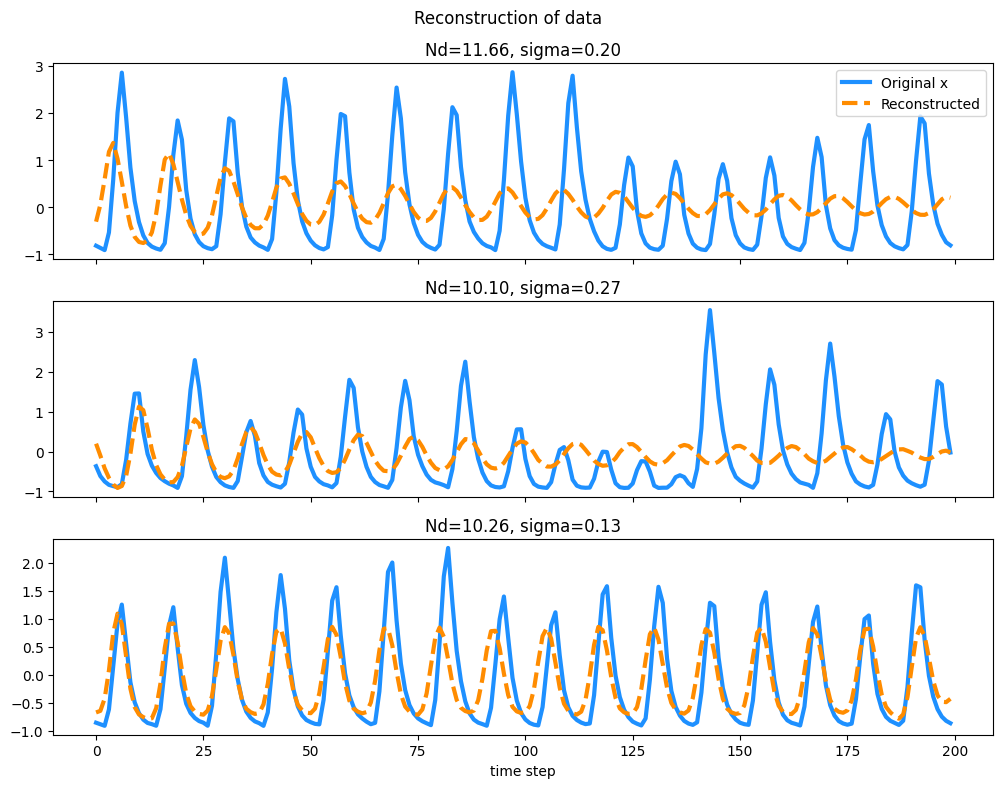

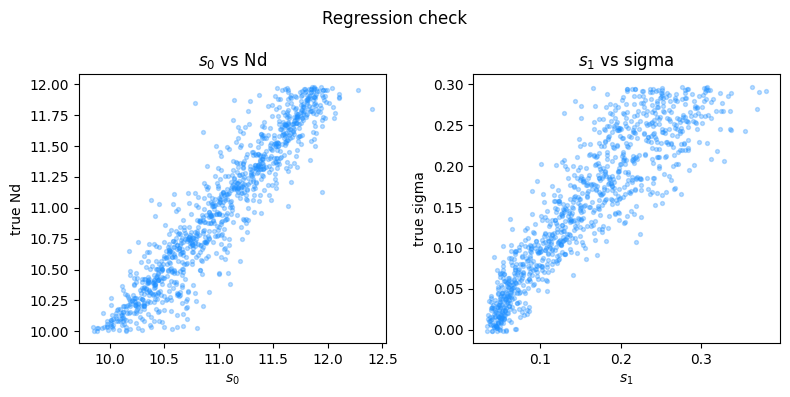

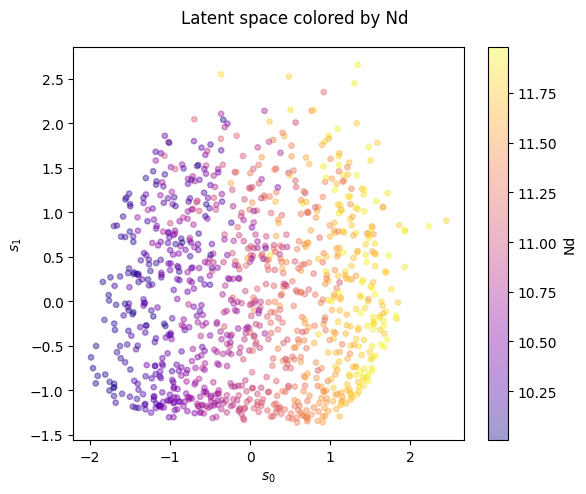

In [34]:
priors = {
    "tau": (1,5), 
    "T": (1,3), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": 2.8,
    "T": 3.7, 
    "Nd": None,
    "sigma": None, 
    "Bmax": 5
}

USE_FOURIER = False # if False, the Time Space is used for X

model, s, x_hat = experiment(fixed, priors,
                              n_train=10000, n_test=1000,
                              n_summary=3, epochs=200,
                              train_model=False)

## Vary $\tau$ and $T$

Generating training data...
Generated 10000/10000 samples
Saved → data/10000__None-None-11-0.05-5__tau=1,5_T=1,3__time

Generating test data...
Generated 1000/1000 samples
Saved → data/1000__None-None-11-0.05-5__tau=1,5_T=1,3__time

Done.
Loaded ← data/10000__None-None-11-0.05-5__tau=1,5_T=1,3__time
Loaded ← data/1000__None-None-11-0.05-5__tau=1,5_T=1,3__time

Training...

Epoch  20, Loss: 0.8921, LR: 8.18e-04
Epoch  40, Loss: 0.8914, LR: 6.69e-04
Epoch  60, Loss: 0.8901, LR: 5.47e-04
Epoch  80, Loss: 0.8898, LR: 4.48e-04
Epoch 100, Loss: 0.8906, LR: 3.66e-04
Epoch 120, Loss: 0.8911, LR: 2.99e-04
Epoch 140, Loss: 0.8902, LR: 2.45e-04
Epoch 160, Loss: 0.8270, LR: 2.00e-04
Epoch 180, Loss: 0.6779, LR: 1.64e-04
Epoch 200, Loss: 0.6001, LR: 1.34e-04


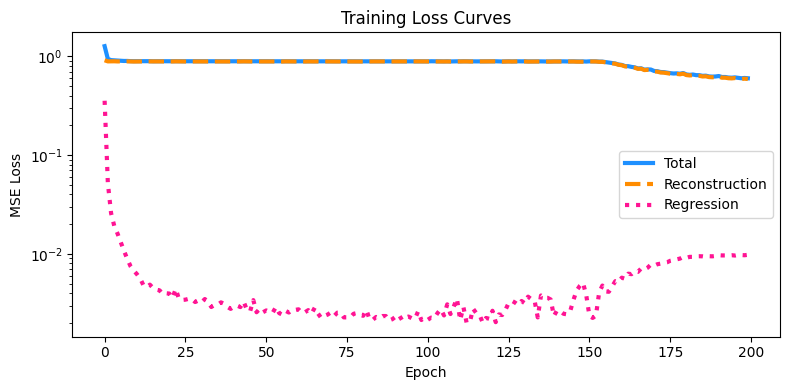

Model saved → models/enca__None-None-11-0.05-5__tau=1,5_T=1,3__time__3summary.pt

----------------------------------------------------------------------------------------------------
Evaluating on test set...


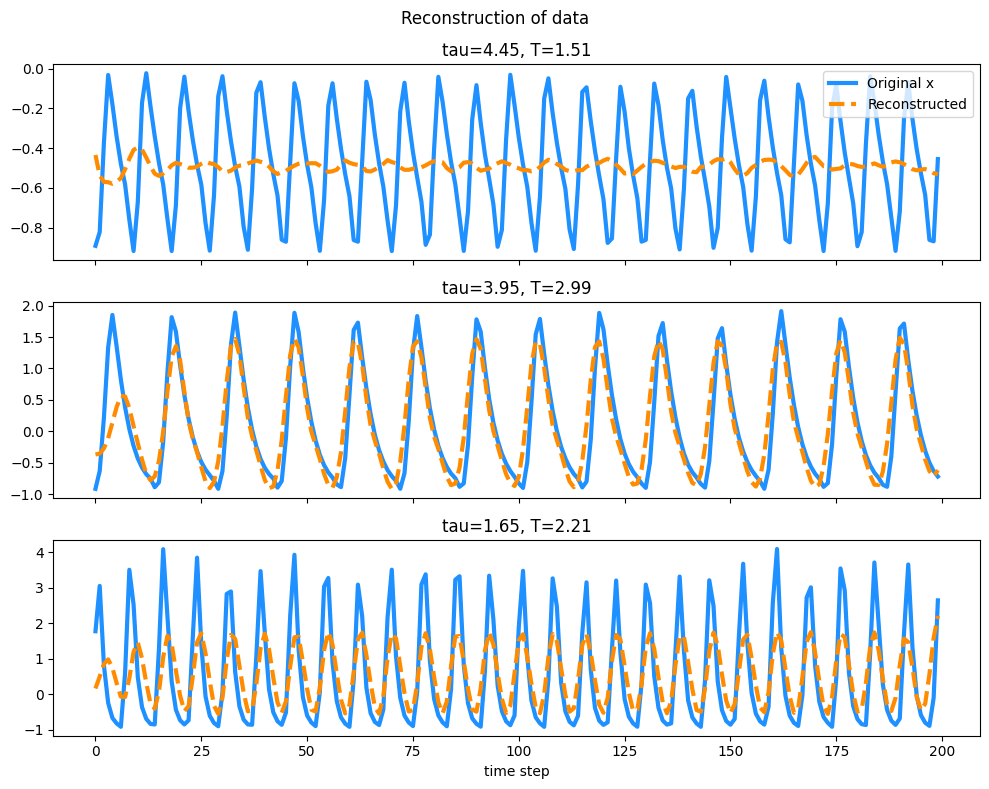

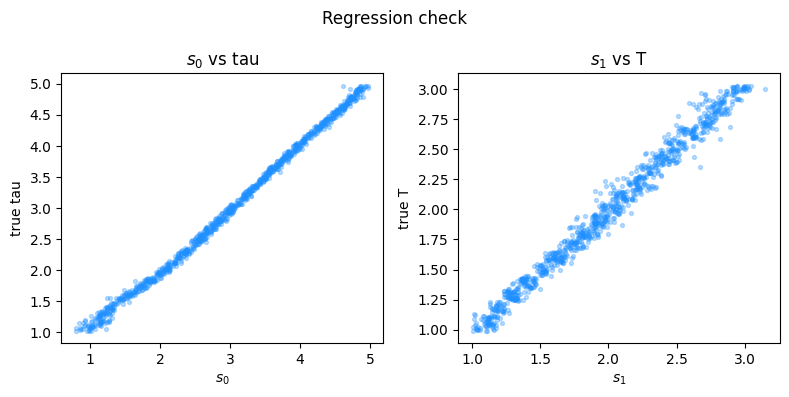

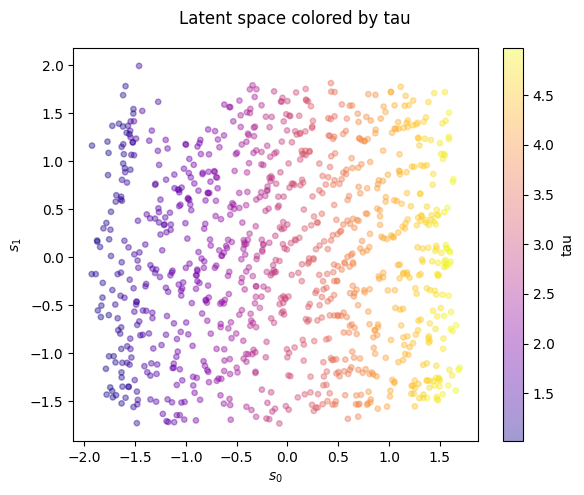

In [35]:
priors = {
    "tau": (1,5), 
    "T": (1,3), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": None,
    "T": None,
    "Nd": 11,
    "sigma": 0.05,
    "Bmax": 5
}

USE_FOURIER = False # if False, the Time Space is used for X

model, s, x_hat = experiment(fixed, priors,
                              n_train=10000, n_test=1000,
                              n_summary=3, epochs=200,
                              train_model=False)

---
# Fixing 4 parameters 
## Vary $\tau$, $T$, $N_d$, $\sigma$

In [ ]:
priors = {
    "tau": (1,5), 
    "T": (1,3), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": None,
    "T": None,
    "Nd": None,
    "sigma": None,
    "Bmax": 5
}

USE_FOURIER = False # if False, the Time Space is used for X

model, s, x_hat = experiment(fixed, priors,
                              n_train=20000, n_test=1000,
                              n_summary=6, epochs=200,
                              train_model=False)

Generating training data...
Generated 20000/20000 samples
Saved → data/20000__None-None-None-None-5__tau=1,5_T=1,3_Nd=10,12_sigma=0,0.3__time

Generating test data...
Generated 1000/1000 samples
Saved → data/1000__None-None-None-None-5__tau=1,5_T=1,3_Nd=10,12_sigma=0,0.3__time

Done.
Loaded ← data/20000__None-None-None-None-5__tau=1,5_T=1,3_Nd=10,12_sigma=0,0.3__time
Loaded ← data/1000__None-None-None-None-5__tau=1,5_T=1,3_Nd=10,12_sigma=0,0.3__time

Training...

Epoch  20, Loss: 1.0457, LR: 8.18e-04
Epoch  40, Loss: 1.0038, LR: 6.69e-04


---
# Pushing toward chaos
## $T\in [1,4]$

In [ ]:
priors = {
    "tau": (1,5), 
    "T": (1,4), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": None,
    "T": None,
    "Nd": 11,
    "sigma": 0.05,
    "Bmax": 5
}

USE_FOURIER = False # if False, the Time Space is used for X

model, s, x_hat = experiment(fixed, priors,
                              n_train=10000, n_test=1000,
                              n_summary=3, epochs=200,
                              train_model=False)

## $T\in[1,5]$

In [ ]:
priors = {
    "tau": (1,5), 
    "T": (1,5), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": None,
    "T": None,
    "Nd": 11,
    "sigma": 0.05,
    "Bmax": 5
}

USE_FOURIER = False # if False, the Time Space is used for X

model, s, x_hat = experiment(fixed, priors,
                              n_train=10000, n_test=1000,
                              n_summary=3, epochs=200,
                              train_model=False)

## $T\in[1,7]$

In [ ]:
priors = {
    "tau": (1,5), 
    "T": (1,7), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": None,
    "T": None,
    "Nd": 11,
    "sigma": 0.05,
    "Bmax": 5
}

USE_FOURIER = False # if False, the Time Space is used for X

model, s, x_hat = experiment(fixed, priors,
                              n_train=10000, n_test=1000,
                              n_summary=3, epochs=200,
                              train_model=False)

The method works well in the non-chaotic regime, but if we push it towards chaos, it breaks down.\
For this reason, the Fourier space can be a potential solution.

# Fourier Space
Apply FFT to $X$ before the encoder.

## Vary $\tau$ and $T$, with $T\in[1,7]$

In [ ]:
priors = {
    "tau": (1,5), 
    "T": (1,7), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": None,
    "T": None,
    "Nd": 11,
    "sigma": 0.05,
    "Bmax": 5
}

USE_FOURIER = True # if False, the Time Space is used for X

model, s, x_hat = experiment(fixed, priors,
                              n_train=10000, n_test=1000,
                              n_summary=3, epochs=200,
                              train_model=False)

## Vary $\tau$, $T$, $N_d$, $\sigma$ 

In [ ]:
priors = {
    "tau": (1,5), 
    "T": (1,3), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": None,
    "T": None,
    "Nd": None,
    "sigma": None,
    "Bmax": 5
}

USE_FOURIER = True # if False, the Time Space is used for X

model, s, x_hat = experiment(fixed, priors,
                              n_train=20000, n_test=1000,
                              n_summary=5, epochs=200,
                              train_model=False)

Using paper priors

In [ ]:
priors = {
    "tau": (0.1,10), 
    "T": (0.1,10), 
    "Nd": (0,15), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": None,
    "T": None,
    "Nd": None,
    "sigma": None,
    "Bmax": 5
}

USE_FOURIER = True # if False, the Time Space is used for X

model, s, x_hat = experiment(fixed, priors,
                              n_train=20000, n_test=1000,
                              n_summary=6, epochs=500,
                              train_model=False)

# <font color='red'>TODO:</font>
- retrain every network in the way it is done below

In [ ]:
priors = {
    "tau": (1,5), 
    "T": (1,3), 
    "Nd": (10,12), 
    "sigma": (0,0.3), 
    "Bmax": (5,5)
}
fixed = {
    "tau": 2.8,
    "T": 3.7, 
    "Nd": None, 
    "sigma": None, 
    "Bmax": 5
}

USE_FOURIER = False # if False, the Time Space is used for X

model, s, x_hat = experiment(fixed, priors,
                              n_train=10000, n_test=1000,
                              n_summary=4, epochs=200,
                              train_model=False)